In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Input
from tensorflow.keras.datasets import fashion_mnist

(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [3]:
from datetime import datetime
from pathlib import Path

# Model/training controls (edit these values only).
EPOCHS = 10
BATCH_SIZE = 5
HIDDEN_LAYER_SIZES = [5, 5, 5]
HIDDEN_ACTIVATION = "relu"
OUTPUT_UNITS = 10
OUTPUT_ACTIVATION = "sigmoid"
LEARNING_RATE = 0.001
OPTIMIZER_NAME = "adam"
LOSS_NAME = "sparse_categorical_crossentropy"
METRICS = ["Accuracy"]

# Logging controls.
# LOG_WORKBOOK = Path("fashion_nn_log.xlsx")

In [4]:
print("My train data Shape:", train_data.shape)
print("My train labels :", train_labels.shape)
print("Maximum label : ", train_labels.max())

My train data Shape: (60000, 28, 28)
My train labels : (60000,)
Maximum label :  9


Text(0.5, 1.0, 'Bag')

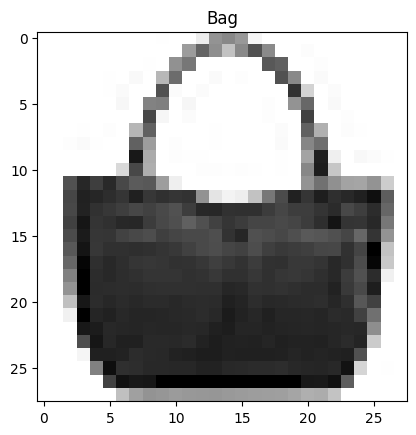

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
index_of_choice = 100
plt.imshow(train_data[index_of_choice],cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

In [6]:
train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=train_data[0].shape)
])

for units in HIDDEN_LAYER_SIZES:
    model.add(tf.keras.layers.Dense(units, activation=HIDDEN_ACTIVATION))

model.add(tf.keras.layers.Dense(OUTPUT_UNITS, activation=OUTPUT_ACTIVATION))

if OPTIMIZER_NAME.lower() == "adam":
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
else:
    raise ValueError(f"Unsupported OPTIMIZER_NAME: {OPTIMIZER_NAME}")

if LOSS_NAME == "sparse_categorical_crossentropy":
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
else:
    raise ValueError(f"Unsupported LOSS_NAME: {LOSS_NAME}")

model.compile(loss=loss_fn,
              optimizer=optimizer,
              metrics=METRICS)

norm_history = model.fit(
    train_data_norm,
    train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(test_data_norm, test_labels)
 )

c:\Users\Thijs\Desktop\DeAi school\DEAI_portfolio\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - Accuracy: 0.6935 - loss: 0.8439 - val_Accuracy: 0.7554 - val_loss: 0.6802
Epoch 2/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 50s 4ms/step - Accuracy: 0.7965 - loss: 0.5910 - val_Accuracy: 0.8065 - val_loss: 0.5739
Epoch 3/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step - Accuracy: 0.8163 - loss: 0.5357 - val_Accuracy: 0.8026 - val_loss: 0.5619
Epoch 4/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - Accuracy: 0.8233 - loss: 0.5126 - val_Accuracy: 0.8018 - val_loss: 0.5627
Epoch 5/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - Accuracy: 0.8267 - loss: 0.5002 - val_Accuracy: 0.8124 - val_loss: 0.5382
Epoch 6/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - Accuracy: 0.8298 - loss: 0.4905 - val_Accuracy: 0.8177 - val_loss: 0.5377
Epoch 7/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - Accuracy: 0.8321 - loss: 0.4826 - val_Accuracy: 0.8213 - val_loss: 0.5238
Epoch 8/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - Accuracy: 

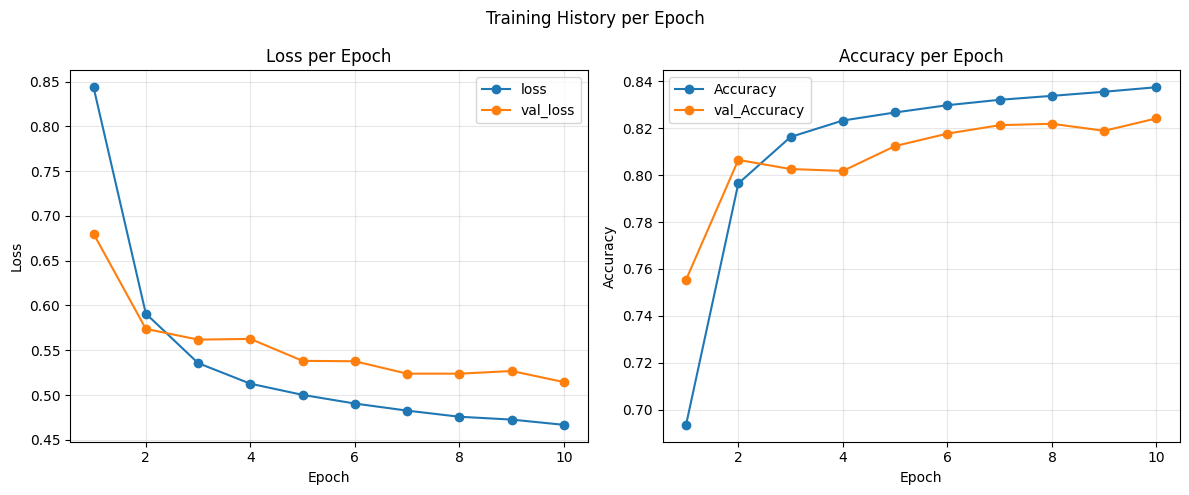

In [8]:
# Graph to show loss and accuracy lines from training history.
history_obj = norm_history.history

acc_key = "accuracy" if "accuracy" in history_obj else "Accuracy"
val_acc_key = "val_accuracy" if "val_accuracy" in history_obj else "val_Accuracy"

epochs_range = range(1, len(history_obj["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, history_obj["loss"], label="loss", marker="o")
if "val_loss" in history_obj:
    axes[0].plot(epochs_range, history_obj["val_loss"], label="val_loss", marker="o")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_range, history_obj.get(acc_key, []), label=acc_key, marker="o")
if val_acc_key in history_obj:
    axes[1].plot(epochs_range, history_obj[val_acc_key], label=val_acc_key, marker="o")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle("Training History per Epoch")
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


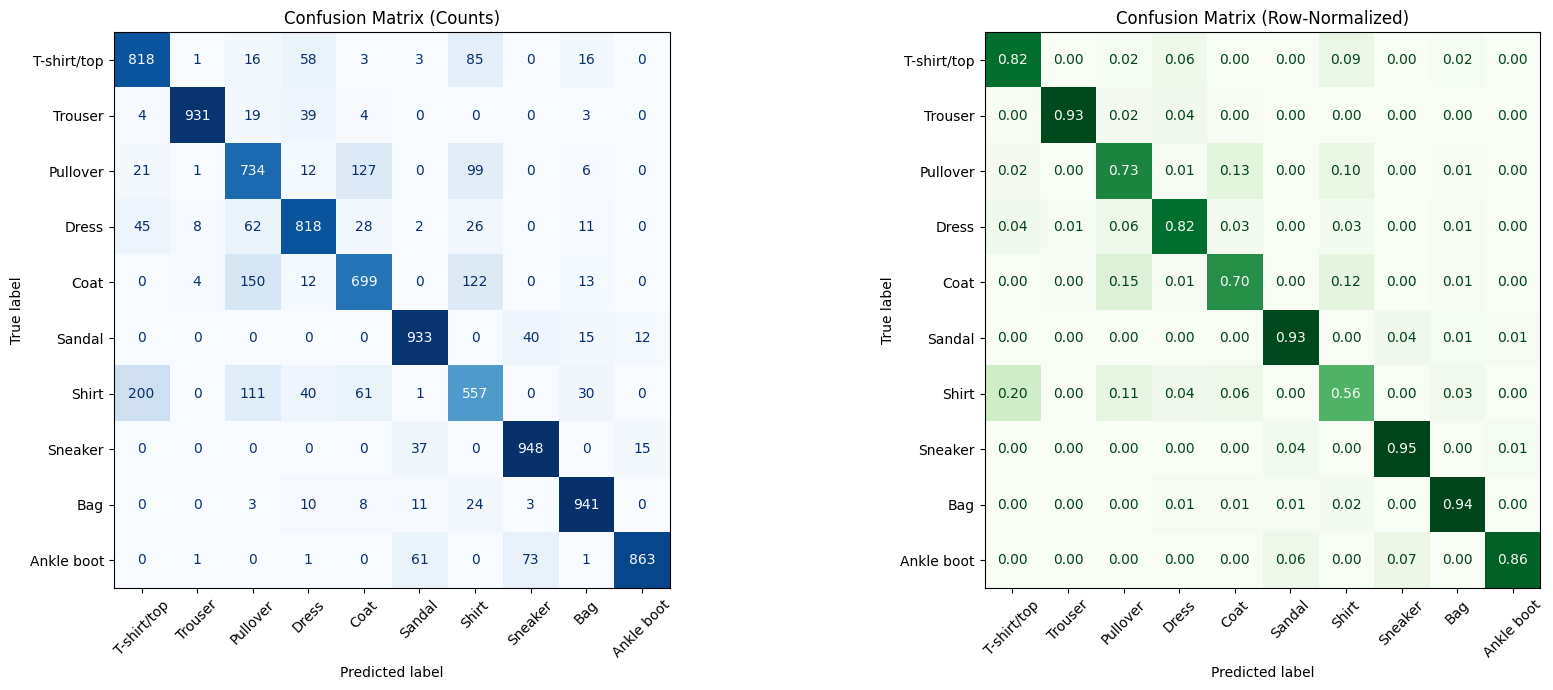

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = model.predict(test_data_norm).argmax(axis=1)
y_true = test_labels
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
 )
axes[0].set_title("Confusion Matrix (Counts)")

ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    ax=axes[1], cmap="Greens", values_format=".2f", colorbar=False, xticks_rotation=45
)
axes[1].set_title("Confusion Matrix (Row-Normalized)")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


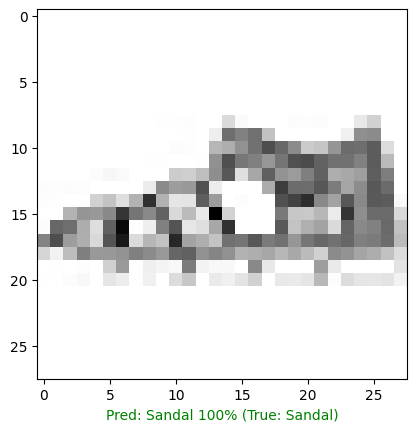

In [10]:
import random
def plot_random_image(model, images, true_labels, classes):
  i = random.randint(0, len(images) - 1)
  image_to_predict = images[i]
  true_positive_image = classes[true_labels[i]]
  pred_probs = model.predict(tf.expand_dims(image_to_predict, axis=0))
  predicted_image = classes[pred_probs.argmax()]
  
  plt.imshow(image_to_predict, cmap=plt.cm.binary)
  if(predicted_image == true_positive_image):
    color = "green"
  else:
    color = "red"

  plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(predicted_image,
                                                    100*tf.reduce_max(pred_probs),
                                                    true_positive_image),color=color)
  
plot_random_image(model,test_data_norm,test_labels,class_names)

In [ ]:
y_probs = model.predict(X_test).ravel()            # probabilities in [0,1]
y_pred = (y_probs >= 0.5).astype(int)              # threshold 0.5 (adjustable)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

In [11]:
# from openpyxl import load_workbook

# run_time = datetime.now()
# run_id = run_time.strftime("%Y%m%d_%H%M%S")
# sheet_name = "runs"

# history_obj = norm_history.history
# acc_key = "accuracy" if "accuracy" in history_obj else "Accuracy"
# val_acc_key = "val_accuracy" if "val_accuracy" in history_obj else "val_Accuracy"

# run_row = pd.DataFrame(
#     [
#         {
#             "run_id": run_id,
#             "timestamp": run_time.isoformat(timespec="seconds"),
#             "epochs": EPOCHS,
#             "batch_size": BATCH_SIZE,
#             "hidden_layer_sizes": str(HIDDEN_LAYER_SIZES),
#             "hidden_activation": HIDDEN_ACTIVATION,
#             "output_units": OUTPUT_UNITS,
#             "output_activation": OUTPUT_ACTIVATION,
#             "optimizer_name": OPTIMIZER_NAME,
#             "learning_rate": LEARNING_RATE,
#             "loss_name": LOSS_NAME,
#             "metrics": str(METRICS),
#             "final_loss": history_obj["loss"][-1] if "loss" in history_obj else np.nan,
#             "final_accuracy": history_obj[acc_key][-1] if acc_key in history_obj else np.nan,
#             "final_val_loss": history_obj["val_loss"][-1] if "val_loss" in history_obj else np.nan,
#             "final_val_accuracy": history_obj[val_acc_key][-1] if val_acc_key in history_obj else np.nan,
#         }
#     ]
# )

# if LOG_WORKBOOK.exists():
#     wb = load_workbook(LOG_WORKBOOK)
#     if sheet_name in wb.sheetnames:
#         startrow = wb[sheet_name].max_row
#         write_header = False
#     else:
#         startrow = 0
#         write_header = True
#     wb.close()

#     with pd.ExcelWriter(
#         LOG_WORKBOOK, engine="openpyxl", mode="a", if_sheet_exists="overlay"
#     ) as writer:
#         run_row.to_excel(
#             writer,
#             sheet_name=sheet_name,
#             index=False,
#             header=write_header,
#             startrow=startrow,
#         )
# else:
#     with pd.ExcelWriter(LOG_WORKBOOK, engine="openpyxl", mode="w") as writer:
#         run_row.to_excel(writer, sheet_name=sheet_name, index=False)

# print(f"Logged run to {LOG_WORKBOOK.resolve()} -> sheet '{sheet_name}' ({len(run_row)} row appended)")